converged SCF energy = -1.40288679189723


Initialize <pyscf.gto.mole.Mole object at 0x11b8d79d0> in <pyscf.scf.rohf.ROHF object at 0x11a5278c0>


Number of spatial MOs: 3
Number of spin orbitals/qubits: 6
Electronic qubit Hamiltonian:
-1.6127332932154474 * I(0) + 0.1208676819803346 * Z(0) + 0.1208676819803346 * Z(1) + 0.12223403165107596 * (Z(0) @ Z(1)) + 0.0003628955902047204 * (Y(0) @ Z(1) @ Z(2) @ Z(3) @ Y(4)) + -0.02036753128176241 * (Y(0) @ Z(2) @ Z(3) @ Y(4)) + 0.0003628955902047204 * (X(0) @ Z(1) @ Z(2) @ Z(3) @ X(4)) + -0.02036753128176241 * (X(0) @ Z(2) @ Z(3) @ X(4)) + 0.0003628955902047204 * (Y(1) @ Z(2) @ Z(3) @ Z(4) @ Y(5)) + -0.02036753128176241 * (Z(0) @ Y(1) @ Z(2) @ Z(3) @ Z(4) @ Y(5)) + 0.0003628955902047204 * (X(1) @ Z(2) @ Z(3) @ Z(4) @ X(5)) + -0.02036753128176241 * (Z(0) @ X(1) @ Z(2) @ Z(3) @ Z(4) @ X(5)) + 0.0386457226793187 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.0386457226793187 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.0386457226793187 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.0386457226793187 * (X(0) @ Y(1) @ Y(2) @ X(3)) + 0.03811590158920267 * (Y(0) @ X(1) @ X(4) @ Y(5)) + -0.03811590158920267 * (Y(0) @ Y(1) @ X(4) @ X

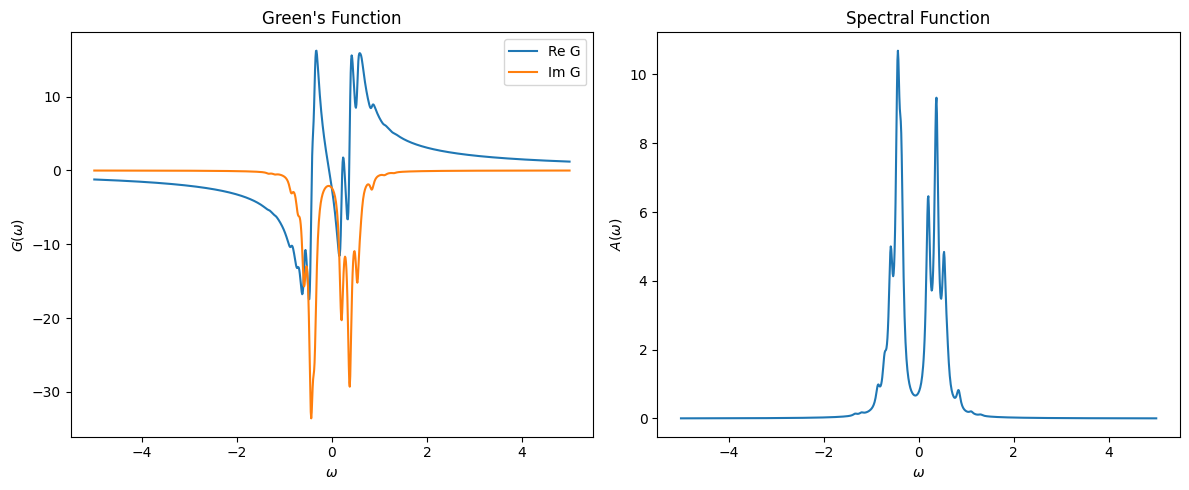

In [6]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Build PySCF molecule
# ============================================================

mol = gto.Mole(
    atom = 'H 0 0 0; H 0 0 1.4; H 0 0 2.8', 
    basis = 'sto-3g', # minimal basis set
    spin = 1 # singlet state
)


# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel() 

myci = fci.FCI(mf, mf.mo_coeff)

nmo = mf.mo_coeff.shape[1]
nelec = mol.nelectron
n_spin_orbitals = 2 * nmo
wires = list(range(n_spin_orbitals))

print("Number of spatial MOs:", nmo)
print("Number of spin orbitals/qubits:", n_spin_orbitals)


# ============================================================
# 2. Build molecular Hamiltonian in MO basis
# ============================================================

one_ao = mf.get_hcore()
two_ao = mol.intor("int2e_sph")

one_mo = np.einsum("pi,pq,qj->ij", mf.mo_coeff, one_ao, mf.mo_coeff)

two_mo = ao2mo.incore.full(two_ao, mf.mo_coeff)
two_mo = np.swapaxes(two_mo, 1, 3)

h1 = one_particle(one_mo)
h2 = two_particle(two_mo)

qubit_hamiltonian = observable(h1, h2, mapping="jordan_wigner")

print("Electronic qubit Hamiltonian:")
print(qubit_hamiltonian)


# ============================================================
# 3. Classical reference energies
# ============================================================

def get_post_HF_energies(mf):
    hf_energy = mf.e_tot

    cisolver = fci.FCI(mf.mol, mf.mo_coeff)
    fci_energy, fci_vector = cisolver.kernel()

    ccsdsolver = cc.CCSD(mf).run()
    ccsd_energy = ccsdsolver.e_tot

    return {
        "hf_energy": hf_energy,
        "fci_energy": fci_energy,
        "ccsd_energy": ccsd_energy,
    }


# ============================================================
# 4. VQE using UCCSD
# ============================================================

def get_vqe_energy_and_state(mf, qubit_hamiltonian, max_steps=100):
    n_wires = qubit_hamiltonian.num_wires
    wires = list(range(n_wires))

    dev = qml.device("default.qubit", wires=n_wires)

    hf_state = qml.qchem.hf_state(mf.mol.nelectron, n_wires)

    singles, doubles = qml.qchem.excitations(mf.mol.nelectron, n_wires)
    s_wires, d_wires = qml.qchem.excitations_to_wires(singles, doubles)

    @qml.qnode(dev)
    def energy_qnode(theta):
        qml.UCCSD(
            theta,
            wires=wires,
            s_wires=s_wires,
            d_wires=d_wires,
            init_state=hf_state,
        )
        return qml.expval(qubit_hamiltonian)

    @qml.qnode(dev)
    def state_qnode(theta):
        qml.UCCSD(
            theta,
            wires=wires,
            s_wires=s_wires,
            d_wires=d_wires,
            init_state=hf_state,
        )
        return qml.state()

    theta = pnp.zeros(len(singles) + len(doubles), requires_grad=True)

    opt = qml.GradientDescentOptimizer(stepsize=0.1)

    for step in range(max_steps):
        theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

        if step % 10 == 0:
            total_energy = electronic_energy + mol.energy_nuc()
            print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

    electronic_energy = energy_qnode(theta)
    total_energy = electronic_energy + mol.energy_nuc()
    psi = state_qnode(theta)

    return {
        "vqe_electronic_energy": electronic_energy,
        "vqe_total_energy": total_energy,
        "vqe_params": theta,
        "vqe_state": psi,
    }


# ============================================================
# 5. Build spin-orbital creation/annihilation matrices
# ============================================================

def build_fermionic_operators(n_spin_orbitals):
    wires = list(range(n_spin_orbitals))

    a = []
    adag = []

    for p in wires:
        a_p = qml.jordan_wigner(qml.FermiA(p))
        adag_p = qml.jordan_wigner(qml.FermiC(p))

        a.append(qml.matrix(a_p, wire_order=wires))
        adag.append(qml.matrix(adag_p, wire_order=wires))

    return a, adag


# ============================================================
# 6. MO-basis spin-summed particle, hole moments and GF
# ============================================================

def compute_mo_moments(psi, qubit_hamiltonian, nmo, nmom=1):
    """
    Compute spin-summed MO-basis particle and hole moments.

    Hole:
        T_h^(n)[i,j] =
        sum_sigma <Psi| a^dag_{i sigma}
        (E0 - H)^n
        a_{j sigma} |Psi>

    Particle:
        T_p^(n)[i,j] =
        sum_sigma <Psi| a_{i sigma}
        (H - E0)^n
        a^dag_{j sigma} |Psi>

    Returns
    -------
    dict with:
        "hole_moments"     : array of shape (nmom+1, nmo, nmo)
        "particle_moments" : array of shape (nmom+1, nmo, nmo)
    """

    n_spin_orbitals = 2 * nmo
    wires = list(range(n_spin_orbitals))

    Hmat = qml.matrix(qubit_hamiltonian, wire_order=wires)

    E0_elec = np.vdot(psi, Hmat @ psi).real

    H_particle = Hmat - E0_elec * np.eye(2**n_spin_orbitals)
    H_hole = E0_elec * np.eye(2**n_spin_orbitals) - Hmat

    a, adag = build_fermionic_operators(n_spin_orbitals)

    particle_moments = np.zeros((nmom + 1, nmo, nmo), dtype=complex)
    hole_moments = np.zeros((nmom + 1, nmo, nmo), dtype=complex)

    particle_powers = [
        np.linalg.matrix_power(H_particle, n)
        for n in range(nmom + 1)
    ]

    hole_powers = [
        np.linalg.matrix_power(H_hole, n)
        for n in range(nmom + 1)
    ]

    for n in range(nmom + 1):

        Hp_n = particle_powers[n]
        Hh_n = hole_powers[n]

        for i in range(nmo):
            for j in range(nmo):

                ia = 2 * i
                ib = 2 * i + 1

                ja = 2 * j
                jb = 2 * j + 1

                particle_moments[n, i, j] = (
                    np.vdot(
                        psi,
                        a[ia] @ Hp_n @ adag[ja] @ psi
                    )
                    +
                    np.vdot(
                        psi,
                        a[ib] @ Hp_n @ adag[jb] @ psi
                    )
                )

                hole_moments[n, i, j] = (
                    np.vdot(
                        psi,
                        adag[ia] @ Hh_n @ a[ja] @ psi
                    )
                    +
                    np.vdot(
                        psi,
                        adag[ib] @ Hh_n @ a[jb] @ psi
                    )
                )

    return {
        "E0_electronic": E0_elec,
        "hole_moments": np.real_if_close(hole_moments),
        "particle_moments": np.real_if_close(particle_moments),
    }

import numpy as np


def hermitize(A):
    return 0.5 * (A + A.conj().T)


def block_hankel_auxiliary_representation(moments, nblocks=None, threshold=1e-10):
    """
    Build a higher-order moment-conserving auxiliary Green's function.

    moments shape:
        (nmom + 1, nmo, nmo)

    If nblocks = K, this uses moments:

        M0, M1, ..., M_{2K-1}

    and builds a K*nmo dimensional auxiliary Hamiltonian.

    Returns
    -------
    eps : pole positions
    residues : list of residue matrices
    X : Dyson orbital amplitudes
    """

    moments = np.asarray(moments, dtype=complex)
    nmom_plus_1, nmo, _ = moments.shape

    if nblocks is None:
        nblocks = nmom_plus_1 // 2

    required_moments = 2 * nblocks

    if nmom_plus_1 < required_moments:
        raise ValueError(
            f"Need moments up to order {required_moments - 1} "
            f"for nblocks={nblocks}."
        )

    dim = nblocks * nmo

    # Block overlap matrix S
    # S_ab = M_{a+b}
    S = np.zeros((dim, dim), dtype=complex)

    # Block shifted moment matrix T
    # T_ab = M_{a+b+1}
    T = np.zeros((dim, dim), dtype=complex)

    for a in range(nblocks):
        for b in range(nblocks):
            S[
                a*nmo:(a+1)*nmo,
                b*nmo:(b+1)*nmo
            ] = moments[a + b]

            T[
                a*nmo:(a+1)*nmo,
                b*nmo:(b+1)*nmo
            ] = moments[a + b + 1]

    S = hermitize(S)
    T = hermitize(T)

    # Remove numerically null directions of S
    svals, U = np.linalg.eigh(S)
    keep = svals > threshold

    if np.count_nonzero(keep) == 0:
        raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

    svals = svals[keep]
    U = U[:, keep]

    S_inv_sqrt = U @ np.diag(1.0 / np.sqrt(svals))

    # Orthogonalized auxiliary Hamiltonian
    F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
    F = hermitize(F)

    eps, C = np.linalg.eigh(F)

    # Moment coupling matrix:
    # B = [M0, M1, ..., M_{K-1}]^T
    B = np.zeros((dim, nmo), dtype=complex)

    for a in range(nblocks):
        B[a*nmo:(a+1)*nmo, :] = moments[a]

    # Dyson orbital amplitudes
    X = B.conj().T @ S_inv_sqrt @ C

    residues = []

    for n in range(len(eps)):
        x = X[:, n:n+1]
        residues.append(x @ x.conj().T)

    print("moments shape:", moments.shape)
    print("nblocks:", nblocks)
    print("S dimension:", S.shape)
    print("S eigenvalues:", np.linalg.eigvalsh(S))
    print("kept:", np.count_nonzero(np.linalg.eigvalsh(S) > threshold))

    return eps, residues, X


def greens_function_from_moments(
    hole_moments,
    particle_moments,
    omega_grid,
    eta=0.05,
    nblocks=None,
):
    """
    Build G(omega) and A(omega) from higher-order hole/particle moments.

    Uses a block-Hankel moment reconstruction.
    """

    hole_moments = np.asarray(hole_moments, dtype=complex)
    particle_moments = np.asarray(particle_moments, dtype=complex)

    eps_h, residues_h, Xh = block_hankel_auxiliary_representation(
        hole_moments,
        nblocks=nblocks,
    )

    eps_p, residues_p, Xp = block_hankel_auxiliary_representation(
        particle_moments,
        nblocks=nblocks,
    )

    nmo = hole_moments.shape[1]

    omega_h = -np.abs(eps_h)
    omega_p = +np.abs(eps_p)

    G_w = np.zeros((len(omega_grid), nmo, nmo), dtype=complex)
    G_h_w = np.zeros_like(G_w)
    G_p_w = np.zeros_like(G_w)

    for iw, omega in enumerate(omega_grid):

        G_h = np.zeros((nmo, nmo), dtype=complex)
        G_p = np.zeros((nmo, nmo), dtype=complex)

        for pole, R in zip(omega_h, residues_h):
            G_h += R / (omega - pole + 1j * eta)

        for pole, R in zip(omega_p, residues_p):
            G_p += R / (omega - pole + 1j * eta)

        G_h_w[iw] = G_h
        G_p_w[iw] = G_p
        G_w[iw] = G_h + G_p

    A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
    A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
    A = A_h + A_p

    return {
        "omega": omega_grid,
        "G": G_w,
        "G_hole": G_h_w,
        "G_particle": G_p_w,
        "A": A,
        "A_hole": A_h,
        "A_particle": A_p,
        "hole_poles": eps_h,
        "particle_poles": eps_p,
        "physical_hole_poles": omega_h,
        "physical_particle_poles": omega_p,
        "hole_residues": residues_h,
        "particle_residues": residues_p,
        "hole_dyson_orbitals": Xh,
        "particle_dyson_orbitals": Xp,
    }

def galitskii_migdal_energy(one_mo, hole_moments, nuclear_repulsion_energy=0.0):
    """
    Galitskii-Migdal energy from spin-summed MO-basis hole moments.

    For RHF/spin-summed moments:

        E_elec = 1/2 [ Tr(T_h^(0) h) + Tr(T_h^(1)) ]

    """

    hole_moments = np.asarray(hole_moments, dtype=complex)

    if hole_moments.shape[0] < 2:
        raise ValueError("Need hole moments up to first order.")

    T0_hole = hole_moments[0]
    T1_hole = hole_moments[1]

    E_elec = 0.5 * (
        np.einsum("ij,ji->", T0_hole, one_mo)
        + np.trace(T1_hole)
    ).real

    return {
        "electronic": E_elec,
        "total": E_elec + nuclear_repulsion_energy,
    }
    
# ============================================================
# 7. Run everything
# ============================================================

pyscf_outputs = get_post_HF_energies(mf)
vqe_outputs = get_vqe_energy_and_state(mf, qubit_hamiltonian, max_steps=100)

moments = compute_mo_moments(
    psi=vqe_outputs["vqe_state"],
    qubit_hamiltonian=qubit_hamiltonian,
    nmo=nmo,
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = galitskii_migdal_energy(
    one_mo=one_mo,
    hole_moments=hole_moments,
    nuclear_repulsion_energy=mol.energy_nuc(),
)


print("\n" + 60 * "-")
print("Reference energies")
print("HF energy:   ", pyscf_outputs["hf_energy"])
print("FCI energy:  ", pyscf_outputs["fci_energy"])
print("CCSD energy: ", pyscf_outputs["ccsd_energy"])
print("VQE energy:  ", vqe_outputs["vqe_total_energy"])
print('Galitskii-Migdal energy from VQE state:', gm["total"])


print("\n" + 60 * "-")
omega_grid = np.linspace(-5, 5, 1000)
gf_data = greens_function_from_moments(
    hole_moments=moments["hole_moments"],
    particle_moments=moments["particle_moments"],
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,       # uses M0-M3
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()

converged SCF energy = -1.46140279190796  <S^2> = 1.1258511  2S+1 = 2.3459336
Number alpha MOs: 3
Number beta MOs:  3
Number spin orbitals/qubits: 6
N alpha: 2
N beta:  1
N total: 3
Qubit Hamiltonian:
(-1.6127332932154494+0j) * I([0, 1, 2, 3, 4, 5]) + (0.0977904112381621+0j) * Z(0) + (-0.06760504232860082+0j) * (Y(0) @ Z(1) @ Y(2)) + (-0.06760504232860082+0j) * (X(0) @ Z(1) @ X(2)) + (0.03517304973162403+0j) * Z(1) + (-0.07717610344401914+0j) * Z(2) + (0.09751696411836752+0j) * Z(3) + (-0.06795742096655029+0j) * (Y(3) @ Z(4) @ Y(5)) + (-0.06795742096655029+0j) * (X(3) @ Z(4) @ X(5)) + (0.03517304973162419+0j) * Z(4) + (-0.07690265632422458+0j) * Z(5) + (0.052766488289050714+0j) * (Z(0) @ Z(1)) + (0.08774498011644102+0j) * (Z(0) @ Z(2)) + (-0.015580232714435822+0j) * (Y(0) @ Y(2)) + (-0.015580232714435822+0j) * (X(0) @ X(2)) + (0.10867942188726443+0j) * (Z(0) @ Z(3)) + (-0.0011833683713464468+0j) * (Z(0) @ Y(3) @ Z(4) @ Y(5)) + (-0.0011833683713464468+0j) * (Z(0) @ X(3) @ Z(4) @ X(5)) +

/var/folders/zr/4vw4vn85503741g0z7bzhc440000gn/T/ipykernel_24413/4214141832.py:452: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(



SciPy result:
Success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final electronic energy: -2.406362097046536
Final total energy: -1.46140279183225

------------------------------------------------------------
Reference energies
HF energy:    -1.4614027919079602
FCI energy:   -1.4963558778980208
CCSD energy:  -1.4963558683681768
VQE energy:   -1.46140279183225
GM energy:    -1.4614027918318966

Moment checks
Tr T_h^0: 2.999999999999792
Expected N: 3
Tr T_p^0: 2.999999999999806
Expected holes: 3
moments shape: (6, 6, 6)
nblocks: 3
S dimension: (18, 18)
S eigenvalues: [-1.20416618e-16 -3.41113245e-18  1.10894283e-19  1.07222557e-17
  3.41368597e-17  5.17081566e-17  7.77795975e-17  2.39757160e-15
  2.61877025e-14  7.05392875e-14  6.68540902e-04  1.29015211e-03
  3.65502325e-02  4.32639204e-02  6.47055846e-02  1.23141045e+00
  1.26300878e+00  1.34592194e+00]
kept: 8
moments shape: (6, 6, 6)
nblocks: 3
S dimension: (18, 18)
S eigenvalues: [-1.47864473e-17  1.3201436

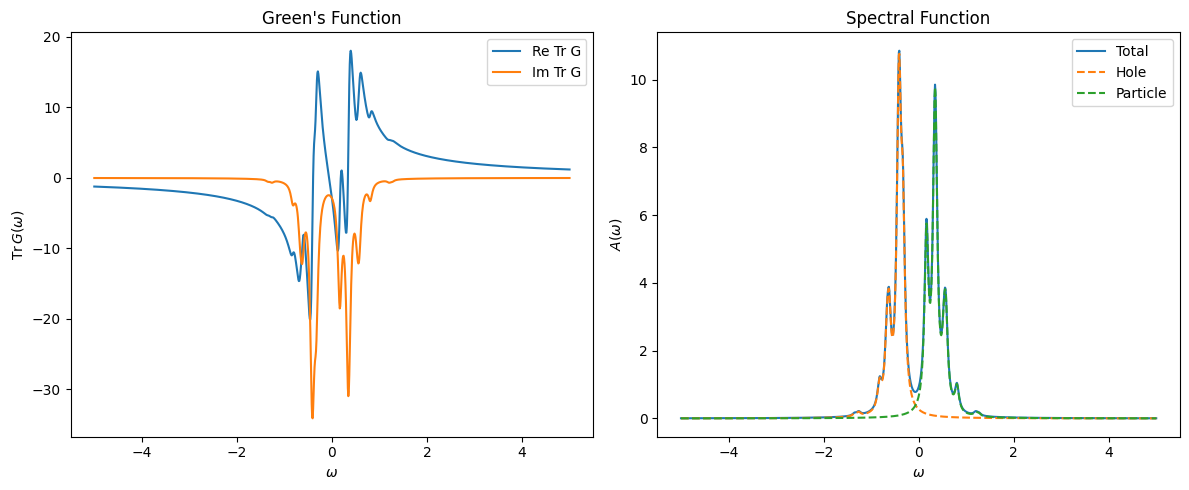

In [5]:
import pennylane as qml
from pennylane import numpy as pnp
from scipy.optimize import minimize

from pyscf import gto, scf, fci, cc, ao2mo
import numpy as np
import matplotlib.pyplot as plt



# ============================================================
# 2. UHF orbital helpers
# ============================================================

def get_uhf_mo_coeffs(mf):
    """
    PySCF UHF stores mo_coeff as shape (2, nao, nmo).
    Returns C_alpha, C_beta.
    """
    C = np.asarray(mf.mo_coeff)

    if C.ndim != 3:
        raise ValueError("This refactor expects a UHF mean-field object.")

    return C[0], C[1]


def get_uhf_dimensions(mf):
    Ca, Cb = get_uhf_mo_coeffs(mf)

    nmo_a = Ca.shape[1]
    nmo_b = Cb.shape[1]
    nso = nmo_a + nmo_b

    return nmo_a, nmo_b, nso


# ============================================================
# 3. Build UHF spin-orbital integrals
# ============================================================

def build_uhf_spin_orbital_one_body(mf):
    """
    Build spin-orbital h[p,q] in block ordering:

        [alpha MOs..., beta MOs...]

    h_spin =
        [ h_alpha   0      ]
        [ 0         h_beta ]
    """

    hcore = mf.get_hcore()
    Ca, Cb = get_uhf_mo_coeffs(mf)

    h_a = Ca.T @ hcore @ Ca
    h_b = Cb.T @ hcore @ Cb

    nmo_a = h_a.shape[0]
    nmo_b = h_b.shape[0]
    nso = nmo_a + nmo_b

    h_spin = np.zeros((nso, nso), dtype=complex)

    h_spin[:nmo_a, :nmo_a] = h_a
    h_spin[nmo_a:, nmo_a:] = h_b

    return h_spin


def build_uhf_spin_orbital_two_body(mf):
    eri_ao = mf.mol.intor("int2e_sph")
    Ca, Cb = get_uhf_mo_coeffs(mf)

    C = [Ca, Cb]
    nmo = [Ca.shape[1], Cb.shape[1]]

    nmo_a, nmo_b = nmo
    nso = nmo_a + nmo_b

    eri_cache = {}

    for sp in [0, 1]:
        for sr in [0, 1]:
            for sq in [0, 1]:
                for ss in [0, 1]:
                    # Only need spin-conserving blocks:
                    # spin(p)=spin(r), spin(q)=spin(s)
                    if sp != sr or sq != ss:
                        continue

                    eri_cache[(sp, sr, sq, ss)] = ao2mo.incore.general(
                        eri_ao,
                        (C[sp], C[sr], C[sq], C[ss]),
                        compact=False,
                    ).reshape(
                        nmo[sp], nmo[sr], nmo[sq], nmo[ss]
                    )

    def spin_and_local_index(p):
        if p < nmo_a:
            return 0, p
        return 1, p - nmo_a

    g_spin = np.zeros((nso, nso, nso, nso), dtype=complex)

    for p in range(nso):
        sp, ip = spin_and_local_index(p)

        for q in range(nso):
            sq, iq = spin_and_local_index(q)

            for r in range(nso):
                sr, ir = spin_and_local_index(r)

                if sp != sr:
                    continue

                for s in range(nso):
                    ss, is_ = spin_and_local_index(s)

                    if sq != ss:
                        continue

                    eri = eri_cache[(sp, sr, sq, ss)]
                    g_spin[p, q, r, s] = eri[ip, ir, iq, is_]

    return g_spin

def build_qubit_hamiltonian_from_spin_orbital_integrals(
    h_spin,
    g_spin,
    cutoff=1e-12,
):
    """
    Build qubit Hamiltonian from spin-orbital integrals.

    H =
        sum_pq h[p,q] a_p^dag a_q
        + 1/2 sum_pqrs g[p,q,r,s] a_p^dag a_q^dag a_s a_r
    """

    nso = h_spin.shape[0]

    fermi_sentence = qml.FermiSentence({})

    # One-body terms
    for p in range(nso):
        for q in range(nso):
            coeff = h_spin[p, q]

            if abs(coeff) > cutoff:
                word = qml.FermiWord({
                    (0, p): "+",
                    (1, q): "-",
                })
                fermi_sentence += qml.FermiSentence({word: coeff})

    # Two-body terms
    for p in range(nso):
        for q in range(nso):
            for r in range(nso):
                for s in range(nso):
                    coeff = 0.5 * g_spin[p, q, r, s]

                    if abs(coeff) > cutoff:
                        word = qml.FermiWord({
                            (0, p): "+",
                            (1, q): "+",
                            (2, s): "-",
                            (3, r): "-",
                        })
                        fermi_sentence += qml.FermiSentence({word: coeff})

    qubit_hamiltonian = qml.jordan_wigner(fermi_sentence)
    qubit_hamiltonian = qml.simplify(qubit_hamiltonian)

    return qubit_hamiltonian

def get_post_HF_energies(mf):
    outputs = {"hf_energy": mf.e_tot}

    try:
        cisolver = fci.FCI(mf.mol, mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
    except Exception as err:
        outputs["fci_energy"] = None
        print("FCI failed:", err)

    try:
        ccsdsolver = cc.UCCSD(mf).run()
        outputs["ccsd_energy"] = ccsdsolver.e_tot
    except Exception as err:
        outputs["ccsd_energy"] = None
        print("UCCSD failed:", err)

    return outputs

def uhf_hf_state(mf):
    """
    Build HF occupation vector in ordering:

        [alpha MOs..., beta MOs...]

    For UHF:
        alpha occupied: first N_alpha alpha orbitals
        beta occupied: first N_beta beta orbitals
    """

    nalpha, nbeta = mf.mol.nelec
    nmo_a, nmo_b, nso = get_uhf_dimensions(mf)

    occ = np.zeros(nso, dtype=int)

    occ[:nalpha] = 1
    occ[nmo_a:nmo_a + nbeta] = 1

    return occ

def uhf_spin_conserving_excitations(mf):
    nalpha, nbeta = mf.mol.nelec
    nmo_a, nmo_b, nso = get_uhf_dimensions(mf)

    alpha_occ = list(range(nalpha))
    alpha_vir = list(range(nalpha, nmo_a))

    beta_occ = list(range(nmo_a, nmo_a + nbeta))
    beta_vir = list(range(nmo_a + nbeta, nso))

    singles = []

    # alpha -> alpha
    for i in alpha_occ:
        for a in alpha_vir:
            singles.append([i, a])

    # beta -> beta
    for i in beta_occ:
        for a in beta_vir:
            singles.append([i, a])

    doubles = []

    occupied = alpha_occ + beta_occ
    virtual = alpha_vir + beta_vir

    for x, i in enumerate(occupied):
        for j in occupied[x + 1:]:
            for y, a in enumerate(virtual):
                for b in virtual[y + 1:]:

                    # conserve total N_alpha and N_beta
                    occ_alpha_count = int(i < nmo_a) + int(j < nmo_a)
                    vir_alpha_count = int(a < nmo_a) + int(b < nmo_a)

                    if occ_alpha_count == vir_alpha_count:
                        doubles.append([i, j, a, b])

    return singles, doubles

def uhf_number_conserving_excitations(mf):
    occ = uhf_hf_state(mf)
    nso = len(occ)

    occupied = [i for i in range(nso) if occ[i] == 1]
    virtual = [i for i in range(nso) if occ[i] == 0]

    singles = []
    for i in occupied:
        for a in virtual:
            singles.append([i, a])

    doubles = []
    for x, i in enumerate(occupied):
        for j in occupied[x + 1:]:
            for y, a in enumerate(virtual):
                for b in virtual[y + 1:]:
                    doubles.append([i, j, a, b])

    return singles, doubles

def uhf_excitations(mf):
    """
    Build singles/doubles based on the explicit UHF occupation vector.
    """

    occ = uhf_hf_state(mf)
    nso = len(occ)

    occupied = [i for i in range(nso) if occ[i] == 1]
    virtual = [i for i in range(nso) if occ[i] == 0]

    singles = []

    for i in occupied:
        for a in virtual:
            singles.append([i, a])

    doubles = []

    for x, i in enumerate(occupied):
        for j in occupied[x + 1:]:
            for y, a in enumerate(virtual):
                for b in virtual[y + 1:]:
                    doubles.append([i, j, a, b])

    return singles, doubles

def excitations_to_wires_general(singles, doubles):
    """
    Handles arbitrary spin-orbital ordering, e.g. [3, 2].
    """

    s_wires = []

    for i, a in singles:
        s_wires.append(
            list(range(min(i, a), max(i, a) + 1))
        )

    d_wires = []

    for i, j, a, b in doubles:
        wires1 = list(range(min(i, a), max(i, a) + 1))
        wires2 = list(range(min(j, b), max(j, b) + 1))

        d_wires.append([wires1, wires2])

    return s_wires, d_wires

def get_vqe_energy_and_state_uhf_scipy(
    mf,
    qubit_hamiltonian,
    maxiter=1000,
    method="BFGS",
    seed=7,
    init_scale=0.05,
):
    n_wires = qubit_hamiltonian.num_wires
    wires = list(range(n_wires))

    dev = qml.device("default.qubit", wires=n_wires)

    hf_state = uhf_hf_state(mf)

    singles, doubles = qml.qchem.excitations(
        mf.mol.nelectron,
        n_wires,
    )

    s_new, d_new = uhf_excitations(mf)

    print('singles compartison:')
    print("UHF singles mine:", s_new)
    print("UHF singles from qchem.excitations:", singles)
    print('doubles compartison:')
    print("UHF doubles mine:", d_new)
    print("UHF doubles from qchem.excitations:", doubles)


    # s_wires, d_wires = qml.qchem.excitations_to_wires(
    #     s_new,
    #     d_new,
    # )

    s_wires, d_wires = excitations_to_wires_general(
        s_new,
        d_new,
    )

    n_params = len(s_new) + len(d_new)

    print("Number singles:", len(singles))
    print("Number doubles:", len(doubles))
    print("Number params:", n_params)

    def make_hamiltonian_real(H, tol=1e-12):
        coeffs, ops = H.terms()

        real_coeffs = []

        for c in coeffs:
            c = complex(c)

            if abs(c.imag) > tol:
                raise ValueError(
                    f"Hamiltonian has genuinely complex coefficient: {c}"
                )

            real_coeffs.append(float(c.real))

        return qml.Hamiltonian(real_coeffs, ops)

    qubit_hamiltonian = make_hamiltonian_real(qubit_hamiltonian)

    @qml.qnode(dev, interface="autograd")
    def energy_qnode(theta):
        qml.UCCSD(
            theta,
            wires=wires,
            s_wires=s_wires,
            d_wires=d_wires,
            init_state=hf_state,
        )
        return qml.expval(qubit_hamiltonian)

    @qml.qnode(dev, interface="autograd")
    def state_qnode(theta):
        qml.UCCSD(
            theta,
            wires=wires,
            s_wires=s_wires,
            d_wires=d_wires,
            init_state=hf_state,
        )
        return qml.state()

    def cost(theta_np):
        theta = pnp.array(theta_np, requires_grad=True)
        return float(energy_qnode(theta))

    grad_fn = qml.grad(energy_qnode)

    def jac(theta_np):
        theta = pnp.array(theta_np, requires_grad=True)
        grad = grad_fn(theta)
        return np.asarray(grad, dtype=float)

    rng = np.random.default_rng(seed)
    theta0 = rng.normal(
        loc=0.0,
        scale=init_scale,
        size=n_params,
    )

    print("Initial total energy:", cost(theta0) + mf.mol.energy_nuc())

    history = []

    def callback(theta_np):
        e_elec = cost(theta_np)
        e_tot = e_elec + mf.mol.energy_nuc()
        history.append(e_tot)

        if len(history) % 10 == 0:
            print(
                f"Iter {len(history):4d} | "
                f"Total VQE energy = {e_tot:.12f}"
            )

    res = minimize(
        fun=cost,
        x0=theta0,
        jac=jac,
        method=method,
        callback=callback,
        options={
            "maxiter": maxiter,
            "gtol": 1e-8,
            "disp": True,
        },
    )

    theta_opt = pnp.array(res.x, requires_grad=False)

    electronic_energy = float(energy_qnode(theta_opt))
    total_energy = electronic_energy + mf.mol.energy_nuc()
    psi = state_qnode(theta_opt)

    print("\nSciPy result:")
    print("Success:", res.success)
    print("Message:", res.message)
    print("Final electronic energy:", electronic_energy)
    print("Final total energy:", total_energy)

    return {
        "vqe_electronic_energy": electronic_energy,
        "vqe_total_energy": total_energy,
        "vqe_params": theta_opt,
        "vqe_state": psi,
        "optimizer_result": res,
        "energy_history": history,
        "singles": singles,
        "doubles": doubles,
    }


def build_fermionic_operators(n_spin_orbitals):
    
    wires = list(range(n_spin_orbitals))

    a = []
    adag = []

    for p in wires:
        a_p = qml.jordan_wigner(qml.FermiA(p))
        adag_p = qml.jordan_wigner(qml.FermiC(p))

        a.append(qml.matrix(a_p, wire_order=wires))
        adag.append(qml.matrix(adag_p, wire_order=wires))

    return a, adag


def compute_spin_orbital_moments(psi, qubit_hamiltonian, n_spin_orbitals, nmom=1):
    """
    Non-spin-traced moments in alpha/beta spin-orbital basis.

    hole_moments[n,p,q] =
        <Psi| a_p^dag (E0-H)^n a_q |Psi>

    particle_moments[n,p,q] =
        <Psi| a_p (H-E0)^n a_q^dag |Psi>
    """

    wires = list(range(n_spin_orbitals))

    Hmat = qml.matrix(qubit_hamiltonian, wire_order=wires)
    E0_elec = np.vdot(psi, Hmat @ psi).real

    H_hole = E0_elec * np.eye(2**n_spin_orbitals) - Hmat
    H_particle = Hmat - E0_elec * np.eye(2**n_spin_orbitals)

    a, adag = build_fermionic_operators(n_spin_orbitals)

    hole_moments = np.zeros(
        (nmom + 1, n_spin_orbitals, n_spin_orbitals),
        dtype=complex,
    )

    particle_moments = np.zeros_like(hole_moments)

    hole_powers = [
        np.linalg.matrix_power(H_hole, n)
        for n in range(nmom + 1)
    ]

    particle_powers = [
        np.linalg.matrix_power(H_particle, n)
        for n in range(nmom + 1)
    ]

    for n in range(nmom + 1):
        Hh_n = hole_powers[n]
        Hp_n = particle_powers[n]

        for p in range(n_spin_orbitals):
            for q in range(n_spin_orbitals):

                hole_moments[n, p, q] = np.vdot(
                    psi,
                    adag[p] @ Hh_n @ a[q] @ psi,
                )

                particle_moments[n, p, q] = np.vdot(
                    psi,
                    a[p] @ Hp_n @ adag[q] @ psi,
                )

    return {
        "E0_electronic": E0_elec,
        "hole_moments": np.real_if_close(hole_moments),
        "particle_moments": np.real_if_close(particle_moments),
    }

def galitskii_migdal_energy_spin_orbital(
    h_spin,
    hole_moments,
    nuclear_repulsion_energy=0.0,
):
    """
    Spin-orbital GM energy.

    E = 1/2 [Tr(T_h^0 h) + Tr(T_h^1)] + E_nuc
    """

    T0 = np.asarray(hole_moments[0], dtype=complex)
    T1 = np.asarray(hole_moments[1], dtype=complex)

    E_elec = 0.5 * (
        np.einsum("pq,qp->", T0, h_spin)
        + np.trace(T1)
    ).real

    return {
        "electronic": E_elec,
        "total": E_elec + nuclear_repulsion_energy,
    }

def hermitize(A):
    return 0.5 * (A + A.conj().T)


def block_hankel_auxiliary_representation(
    moments,
    nblocks=None,
    threshold=1e-10,
    verbose=False,
):
    moments = np.asarray(moments, dtype=complex)
    nmom_plus_1, norb, _ = moments.shape

    if nblocks is None:
        nblocks = nmom_plus_1 // 2

    required_moments = 2 * nblocks

    if nmom_plus_1 < required_moments:
        raise ValueError(
            f"Need moments up to order {required_moments - 1} "
            f"for nblocks={nblocks}."
        )

    dim = nblocks * norb

    S = np.zeros((dim, dim), dtype=complex)
    T = np.zeros((dim, dim), dtype=complex)

    for a in range(nblocks):
        for b in range(nblocks):
            S[a*norb:(a+1)*norb, b*norb:(b+1)*norb] = moments[a + b]
            T[a*norb:(a+1)*norb, b*norb:(b+1)*norb] = moments[a + b + 1]

    S = hermitize(S)
    T = hermitize(T)

    svals, U = np.linalg.eigh(S)
    keep = svals > threshold

    if np.count_nonzero(keep) == 0:
        raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

    U = U[:, keep]
    svals = svals[keep]

    S_inv_sqrt = U @ np.diag(1.0 / np.sqrt(svals))

    F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
    F = hermitize(F)

    eps, C = np.linalg.eigh(F)

    B = np.zeros((dim, norb), dtype=complex)

    for a in range(nblocks):
        B[a*norb:(a+1)*norb, :] = moments[a]

    X = B.conj().T @ S_inv_sqrt @ C

    residues = []

    for n in range(len(eps)):
        x = X[:, n:n+1]
        residues.append(x @ x.conj().T)

    if verbose:
        print("moments shape:", moments.shape)
        print("nblocks:", nblocks)
        print("S dimension:", S.shape)
        print("S eigenvalues:", np.linalg.eigvalsh(S))
        print("kept:", len(svals))

    return eps, residues, X


def greens_function_from_moments(
    hole_moments,
    particle_moments,
    omega_grid,
    eta=0.05,
    nblocks=None,
    threshold=1e-10,
    verbose=False,
):
    eps_h, residues_h, Xh = block_hankel_auxiliary_representation(
        hole_moments,
        nblocks=nblocks,
        threshold=threshold,
        verbose=verbose,
    )

    eps_p, residues_p, Xp = block_hankel_auxiliary_representation(
        particle_moments,
        nblocks=nblocks,
        threshold=threshold,
        verbose=verbose,
    )

    norb = hole_moments.shape[1]

    omega_h = -np.abs(eps_h)
    omega_p = +np.abs(eps_p)

    G_w = np.zeros((len(omega_grid), norb, norb), dtype=complex)
    G_h_w = np.zeros_like(G_w)
    G_p_w = np.zeros_like(G_w)

    for iw, omega in enumerate(omega_grid):

        G_h = np.zeros((norb, norb), dtype=complex)
        G_p = np.zeros((norb, norb), dtype=complex)

        for pole, R in zip(omega_h, residues_h):
            G_h += R / (omega - pole + 1j * eta)

        for pole, R in zip(omega_p, residues_p):
            G_p += R / (omega - pole + 1j * eta)

        G_h_w[iw] = G_h
        G_p_w[iw] = G_p
        G_w[iw] = G_h + G_p

    A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
    A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
    A = A_h + A_p

    return {
        "omega": omega_grid,
        "G": G_w,
        "G_hole": G_h_w,
        "G_particle": G_p_w,
        "A": A,
        "A_hole": A_h,
        "A_particle": A_p,
        "hole_poles": eps_h,
        "particle_poles": eps_p,
        "physical_hole_poles": omega_h,
        "physical_particle_poles": omega_p,
        "hole_residues": residues_h,
        "particle_residues": residues_p,
        "hole_dyson_orbitals": Xh,
        "particle_dyson_orbitals": Xp,
    }

# ============================================================
# 1. Build PySCF molecule and UHF mean field 
# and qubit hamiltonian
# ============================================================

mol = gto.Mole()
mol.atom = "H 0 0 0; H 0 0 1.4; H 0 0 2.8"
mol.basis = "sto-3g"
mol.spin = 1  # N_alpha - N_beta
mol.build()

mf = scf.UHF(mol)
mf.kernel()

na, nb = mol.nelec
nelec = mol.nelectron

nmo_a, nmo_b, n_spin_orbitals = get_uhf_dimensions(mf)
wires = list(range(n_spin_orbitals))

print("Number alpha MOs:", nmo_a)
print("Number beta MOs: ", nmo_b)
print("Number spin orbitals/qubits:", n_spin_orbitals)


print("N alpha:", na)
print("N beta: ", nb)
print("N total:", nelec)

h_spin = build_uhf_spin_orbital_one_body(mf)
g_spin = build_uhf_spin_orbital_two_body(mf)

qubit_hamiltonian = build_qubit_hamiltonian_from_spin_orbital_integrals(
    h_spin=h_spin,
    g_spin=g_spin,
)

print("Qubit Hamiltonian:")
print(qubit_hamiltonian)


pyscf_outputs = get_post_HF_energies(mf)

vqe_outputs = get_vqe_energy_and_state_uhf_scipy(
    mf,
    qubit_hamiltonian,
    maxiter=1000,
    method="L-BFGS-B",
    seed=7,
    init_scale=0.05,
)

moments = compute_spin_orbital_moments(
    psi=vqe_outputs["vqe_state"],
    qubit_hamiltonian=qubit_hamiltonian,
    n_spin_orbitals=n_spin_orbitals,
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = galitskii_migdal_energy_spin_orbital(
    h_spin=h_spin,
    hole_moments=hole_moments,
    nuclear_repulsion_energy=mol.energy_nuc(),
)

print("\n" + 60 * "-")
print("Reference energies")
print("HF energy:   ", pyscf_outputs["hf_energy"])
print("FCI energy:  ", pyscf_outputs["fci_energy"])
print("CCSD energy: ", pyscf_outputs["ccsd_energy"])
print("VQE energy:  ", vqe_outputs["vqe_total_energy"])
print("GM energy:   ", gm["total"])

print("\nMoment checks")
print("Tr T_h^0:", np.trace(hole_moments[0]).real)
print("Expected N:", mol.nelectron)
print("Tr T_p^0:", np.trace(particle_moments[0]).real)
print("Expected holes:", n_spin_orbitals - mol.nelectron)

omega_grid = np.linspace(-5, 5, 1000)

gf_data = greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,
    verbose=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

G_trace = np.trace(gf_data["G"], axis1=1, axis2=2)

axes[0].plot(gf_data["omega"], G_trace.real, label="Re Tr G")
axes[0].plot(gf_data["omega"], G_trace.imag, label="Im Tr G")
axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$\mathrm{Tr}\,G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

axes[1].plot(gf_data["omega"], gf_data["A"], label="Total")
axes[1].plot(gf_data["omega"], gf_data["A_hole"], "--", label="Hole")
axes[1].plot(gf_data["omega"], gf_data["A_particle"], "--", label="Particle")
axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")
axes[1].legend()

plt.tight_layout()
plt.show()